In [313]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [314]:
df=pd.read_csv("used_cars_messy.csv")
df.head(100)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,7214,Mercedes-Benz E-Class,Mercedes-Benz,E-Class,7,68000,Dealer,Diesel,Automatic,13.0,2143.0,201.10,NaN,2450000.0
96,14943,Hyundai Creta,Hyundai,Creta,3,98000,Individual,Diesel,Manual,22.1,1396.0,88.70,5.0,950000.0
97,5586,Maruti Vitara,Maruti,Vitara,4,53892,Dealer,Diesel,Manual,24.3,1248.0,88.50,5.0,780000.0
98,12719,Mercedes-Benz S-Class,Mercedes-Benz,S-Class,7,20001,Dealer,Diesel,Automatic,13.5,2987.0,282.00,5.0,5500000.0


In [315]:
df.shape

(15661, 14)

In [316]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15661 non-null  int64  
 1   car_name           15661 non-null  object 
 2   brand              15661 non-null  object 
 3   model              15661 non-null  object 
 4   vehicle_age        15661 non-null  int64  
 5   km_driven          15661 non-null  object 
 6   seller_type        15661 non-null  object 
 7   fuel_type          15661 non-null  object 
 8   transmission_type  15661 non-null  object 
 9   mileage            14376 non-null  object 
 10  engine             13792 non-null  float64
 11  max_power          14862 non-null  float64
 12  seats              15218 non-null  float64
 13  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), object(8)
memory usage: 1.7+ MB


In [317]:
df.isnull().sum()

Unnamed: 0              0
car_name                0
brand                   0
model                   0
vehicle_age             0
km_driven               0
seller_type             0
fuel_type               0
transmission_type       0
mileage              1285
engine               1869
max_power             799
seats                 443
selling_price         158
dtype: int64

In [318]:
#percentage of null values in a particular column
df.isnull().sum()*100/df.shape[0]

Unnamed: 0            0.000000
car_name              0.000000
brand                 0.000000
model                 0.000000
vehicle_age           0.000000
km_driven             0.000000
seller_type           0.000000
fuel_type             0.000000
transmission_type     0.000000
mileage               8.205095
engine               11.934104
max_power             5.101845
seats                 2.828683
selling_price         1.008876
dtype: float64

In [319]:
#duplicated rows present
df.duplicated().sum()

np.int64(169)

In [320]:
#Duplicated rows info
df[df.duplicated(keep=False)].sort_values('car_name').head(20)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
9347,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
5920,1210,Audi A4,Audi,A4,9,23994,Dealer,Diesel,Automatic,17.11,NaN,174.33,5.0,1275000.0
13398,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
3642,6871,Audi A4,Audi,A4,4,53700,Individual,Diesel,Automatic,18.25,1968.0,187.74,5.0,1760000.0
867,16053,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993.0,NaN,4.0,5600000.0
8441,16053,BMW 6,BMW,6,3,11000,Dealer,Diesel,Automatic,17.09,2993.0,NaN,4.0,5600000.0
4958,11969,BMW X5,BMW,X5,7,68000,Dealer,Diesel,Automatic,11.7,2993.0,245.00,5.0,3200000.0
3709,11969,BMW X5,BMW,X5,7,68000,Dealer,Diesel,Automatic,11.7,2993.0,245.00,5.0,3200000.0
4973,7216,Datsun GO,Datsun,GO,4,23142,Dealer,Petrol,Manual,NaN,1198.0,67.00,5.0,360000.0
11616,7216,Datsun GO,Datsun,GO,4,23142,Dealer,Petrol,Manual,NaN,1198.0,67.00,5.0,360000.0


In [321]:
cat_columns=['car_name','brand','seller_type','fuel_type','transmission_type']

for col in cat_columns:
    unique_values=df[col].unique()
    print(f"\n {col} {len(unique_values)} unique values: ")
    print(sorted(unique_values))
    


 car_name 121 unique values: 
['Audi A4', 'Audi A6', 'Audi A8', 'Audi Q7', 'BMW 3', 'BMW 5', 'BMW 6', 'BMW 7', 'BMW X1', 'BMW X3', 'BMW X4', 'BMW X5', 'BMW Z4', 'Bentley Continental', 'Datsun GO', 'Datsun RediGO', 'Datsun redi-GO', 'Ferrari GTC4Lusso', 'Force Gurkha', 'Ford Aspire', 'Ford Ecosport', 'Ford Endeavour', 'Ford Figo', 'Ford Freestyle', 'Honda Amaze', 'Honda CR', 'Honda CR-V', 'Honda City', 'Honda Civic', 'Honda Jazz', 'Honda WR-V', 'Hyundai Aura', 'Hyundai Creta', 'Hyundai Elantra', 'Hyundai Grand', 'Hyundai Santro', 'Hyundai Tucson', 'Hyundai Venue', 'Hyundai Verna', 'Hyundai i10', 'Hyundai i20', 'ISUZU MUX', 'Isuzu D-Max', 'Isuzu MUX', 'Jaguar F-PACE', 'Jaguar XE', 'Jaguar XF', 'Jeep Compass', 'Jeep Wrangler', 'Kia Carnival', 'Kia Seltos', 'Land Rover Rover', 'Lexus ES', 'Lexus NX', 'Lexus RX', 'MG Hector', 'Mahindra Alturas', 'Mahindra Bolero', 'Mahindra KUV', 'Mahindra KUV100', 'Mahindra Marazzo', 'Mahindra Scorpio', 'Mahindra Thar', 'Mahindra XUV300', 'Mahindra XUV500

In [322]:
#Converting the datatypes
print(df['km_driven'].dtype)

object


In [323]:
print(df['km_driven'].sample(20).tolist())

['38000', '70000', '39000', '64172', '61000', '24000', '90000', '20000', '25358', '55837', '29000', '23000', '47000', '119621', '90000', '90000', '20000', '43043', '102558', '85000']


In [324]:
print(df['mileage'].dtype)

object


In [325]:
print(df['mileage'].sample(100).tolist())

['28.09', '22.07', nan, '23.01', '22.48', '19.7', '18.0', '17.3', '24.3 kmpl', '16.36', '23.84', '21.79', '20.36', '26.21', '20.36', '25.5', '16.8', '15.37', '14.3', '11.1', '15.0', '28.09', '21.79', '25.5', '23.0', '19.33', '16.07', '12.99', '22.54', '19.1', '16.5', '15.6', '23.84', '21.79', '13.96', '25.8', '20.14', '18.6', '25.8', '18.9', '24.0', '21.4', '28.4', '17.0', '20.73', '22.9', nan, '20.92', '26.0', '25.47', '20.36', nan, '20.73', '22.9 kmpl', '18.9', '16.0', '17.0', '25.83', '17.92', '18.6', '26.21', '26.0', '14.84', '25.32', '21.21', '15.1', '16.8', '19.3', '14.75', '16.47', '22.9', nan, '23.0', '28.09', '21.38', nan, '18.9', '19.3', '20.51', '19.67', '24.52', nan, '22.3', '24.7', '15.1', '25.47 kmpl', '19.7', '20.51', '11.3', '22.54', '19.81', nan, '13.0', '17.0', '28.09', '25.2', '21.9', '14.74', '21.7', '13.6']


In [326]:
#It is in object/catalog 
df[df['mileage'].astype(str).str.contains('kmpl')]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
91,14883,Maruti Wagon R,Maruti,Wagon R,4,30000,Individual,CNG,Manual,33.54 kmpl,998.0,67.04,5.0,450000.0
175,9041,Toyota Innova,Toyota,Innova,5,66240,Dealer,Diesel,Manual,13.68 kmpl,2393.0,147.80,7.0,1675000.0
384,8694,Maruti Alto,Maruti,Alto,3,38000,Dealer,Petrol,Manual,22.74 kmpl,796.0,47.30,5.0,325000.0
393,8711,Honda City,Honda,City,5,78236,Dealer,Petrol,Manual,17.4 kmpl,1497.0,NaN,5.0,651000.0
518,17379,Maruti Ciaz,Maruti,Ciaz,1,6003,Trustmark Dealer,Petrol,Manual,21.56 kmpl,1462.0,103.25,5.0,875000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15528,17056,Maruti Alto,Maruti,Alto,8,25000,Individual,Petrol,Manual,22.74 kmpl,796.0,47.30,5.0,210000.0
15554,15211,Renault KWID,Renault,KWID,2,8500,Dealer,Petrol,Automatic,24.04 kmpl,999.0,67.00,5.0,425000.0
15579,12962,Hyundai Creta,Hyundai,Creta,5,55000,Dealer,Diesel,Automatic,17.01 kmpl,NaN,126.20,5.0,990000.0
15618,248,Datsun GO,Datsun,GO,5,33350,Individual,Petrol,Manual,19.44 kmpl,1198.0,67.00,7.0,320000.0


In [327]:
#It is in object/catalog 
df[df['km_driven'].astype(str).str.contains('kms')]

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
80,4871,Mahindra XUV500,Mahindra,XUV500,6,42000 kms,Dealer,Diesel,Manual,15.1,2179.0,140.00,7.0,950000.0
244,15186,Renault Duster,Renault,Duster,5,62000 kms,Individual,Diesel,Manual,19.87,1461.0,83.80,5.0,700000.0
324,2767,Hyundai i20,Hyundai,i20,9,40000 kms,Dealer,Diesel,Manual,21.9,1396.0,NaN,5.0,435000.0
370,18113,Ford Aspire,Ford,Aspire,5,43652 kms,Dealer,Petrol,Manual,18.16,1196.0,86.80,5.0,430000.0
721,3117,Honda City,Honda,City,10,100000 kms,Individual,Petrol,Manual,17.0,1497.0,118.00,5.0,380000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14403,17660,Honda Civic,Honda,Civic,2,16502 kms,Dealer,Petrol,Automatic,16.5,1799.0,139.46,NaN,2100000.0
14977,6415,Maruti Swift,Maruti,Swift,7,70000 kms,Individual,Petrol,Manual,18.6,1197.0,85.80,5.0,370000.0
15170,2436,Honda Amaze,Honda,Amaze,8,31497 kms,Dealer,Petrol,Manual,18.0,1198.0,86.70,5.0,393000.0
15449,7555,Hyundai i20,Hyundai,i20,3,15000 kms,Dealer,Petrol,Manual,18.6,1197.0,81.83,5.0,660000.0


In [328]:
df.describe()

,Unnamed: 0,vehicle_age,engine,max_power,seats,selling_price
count,15661.000000,15661.000000,13792.000000,14862.000000,15218.000000,1.550300e+04
mean,9808.189643,6.036843,1480.489342,100.513582,5.324418,1.032764e+06
std,5642.981540,3.015072,511.446057,42.854632,0.805993,1.607380e+07
min,0.000000,0.000000,793.000000,38.400000,0.000000,5.000000e+02
25%,4901.000000,4.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9858.000000,6.000000,1248.000000,88.500000,5.000000,5.550000e+05
75%,14666.000000,8.000000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,6592.000000,626.000000,9.000000,1.000000e+09


In [329]:
#Fixing of data
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [330]:
#Remove unwanted columns 
df=df.drop(columns=['Unnamed: 0'])
df.head(10)


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
5,Hyundai i10,Hyundai,i10,12,73000,Dealer,Petrol,Manual,20.36,1197.0,78.90,5.0,190000.0
6,Hyundai i20,Hyundai,i20,12,88000,Dealer,Petrol,Manual,18.5,NaN,80.00,5.0,275000.0
7,Maruti Wagon R,Maruti,Wagon R,7,50000,Individual,Petrol,Manual,20.51,NaN,67.04,5.0,351000.0
8,Ford Freestyle,Ford,Freestyle,2,30000,individual,Diesel,Manual,24.4,1498.0,98.63,5.0,775000.0
9,Maruti Swift Dzire,Maruti,Swift Dzire,10,75220,Dealer,Diesel,Manual,19.3,1248.0,73.90,5.0,390000.0


In [331]:
print(f"Unique values before cleaning data: {df['brand'].nunique()}")

df['brand']=df['brand'].str.strip()
print(f"Unique values after cleaning data:{df['brand'].nunique()}")

print(df['brand'].value_counts())

Unique values before cleaning data: 80
Unique values after cleaning data:32
brand
Maruti           5077
Hyundai          3025
Honda            1508
Mahindra         1031
Toyota            806
Ford              802
Volkswagen        634
Renault           550
BMW               443
Tata              435
Mercedes-Benz     339
Skoda             338
Audi              196
Datsun            172
Jaguar             61
Land Rover         51
Jeep               42
Kia                33
Porsche            22
Volvo              20
MG                 19
Mini               17
Nissan             11
Lexus              10
Isuzu               8
Bentley             3
ISUZU               2
Maserati            2
Ferrari             1
Mercedes-AMG        1
Force               1
Rolls-Royce         1
Name: count, dtype: int64


In [332]:
#Fuel
df['fuel_type'].unique()

array(['Diesel', 'CNG', 'Petrol', 'Petrol ', 'DIESEL', ' Petrol',
       'petrol ', 'PETROL', ' Diesel', 'diesel ', 'LPG', 'petrol',
       'diesel', 'Electric'], dtype=object)

In [333]:
#The values have same name and extra spacing/white space 
df['fuel_type']=df['fuel_type'].str.strip().str.title()
df['fuel_type'].unique()


array(['Diesel', 'Cng', 'Petrol', 'Lpg', 'Electric'], dtype=object)

In [334]:
df['fuel_type'].value_counts()

fuel_type
Petrol      7765
Diesel      7544
Cng          302
Lpg           46
Electric       4
Name: count, dtype: int64

In [335]:
#Seller Type
df['seller_type'].unique()

array(['Dealer', 'dealer', 'Individual', 'individual', 'DEALER',
       'Trustmark Dealer', 'Individul', 'Individuall', 'Delaer'],
      dtype=object)

In [336]:
df['seller_type']=df['seller_type'].str.strip().str.title()
df['seller_type'].unique()

array(['Dealer', 'Individual', 'Trustmark Dealer', 'Individul',
       'Individuall', 'Delaer'], dtype=object)

In [337]:
#Still contains the duplicated values so need to replace
seller_dup={
    'Individul':'Individual',
    'Individuall':'Individual',
    'Delaer':'Dealer'
}
df['seller_type']=df['seller_type'].replace(seller_dup)
df['seller_type'].unique()

array(['Dealer', 'Individual', 'Trustmark Dealer'], dtype=object)

In [338]:
df['seller_type'].value_counts()

seller_type
Dealer              9694
Individual          5792
Trustmark Dealer     175
Name: count, dtype: int64

In [339]:
#Numerical Columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15661 non-null  object 
 1   brand              15661 non-null  object 
 2   model              15661 non-null  object 
 3   vehicle_age        15661 non-null  int64  
 4   km_driven          15661 non-null  object 
 5   seller_type        15661 non-null  object 
 6   fuel_type          15661 non-null  object 
 7   transmission_type  15661 non-null  object 
 8   mileage            14376 non-null  object 
 9   engine             13792 non-null  float64
 10  max_power          14862 non-null  float64
 11  seats              15218 non-null  float64
 12  selling_price      15503 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.6+ MB


In [340]:
print(type(df['km_driven']))

<class 'pandas.core.series.Series'>


In [341]:
df['km_driven'].head(1000)

0       67647
1       52000
2       48959
3       82000
4       34000
        ...  
995    110000
996     31000
997     36000
998     21000
999    110000
Name: km_driven, Length: 1000, dtype: object

In [342]:
#Replace the values with '' empty spaces 
df['km_driven']=df['km_driven'].astype(str).str.replace('kms','').str.replace(',','').str.replace('km','')

In [343]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15661 non-null  object 
 1   brand              15661 non-null  object 
 2   model              15661 non-null  object 
 3   vehicle_age        15661 non-null  int64  
 4   km_driven          15661 non-null  object 
 5   seller_type        15661 non-null  object 
 6   fuel_type          15661 non-null  object 
 7   transmission_type  15661 non-null  object 
 8   mileage            14376 non-null  object 
 9   engine             13792 non-null  float64
 10  max_power          14862 non-null  float64
 11  seats              15218 non-null  float64
 12  selling_price      15503 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.6+ MB


In [344]:
#Type cast the column
df['km_driven']=pd.to_numeric(df['km_driven'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15661 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15661 non-null  object 
 1   brand              15661 non-null  object 
 2   model              15661 non-null  object 
 3   vehicle_age        15661 non-null  int64  
 4   km_driven          15661 non-null  int64  
 5   seller_type        15661 non-null  object 
 6   fuel_type          15661 non-null  object 
 7   transmission_type  15661 non-null  object 
 8   mileage            14376 non-null  object 
 9   engine             13792 non-null  float64
 10  max_power          14862 non-null  float64
 11  seats              15218 non-null  float64
 12  selling_price      15503 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 1.6+ MB


In [345]:
#Missing values 
df.isnull().sum()*100/df.shape[0]

car_name              0.000000
brand                 0.000000
model                 0.000000
vehicle_age           0.000000
km_driven             0.000000
seller_type           0.000000
fuel_type             0.000000
transmission_type     0.000000
mileage               8.205095
engine               11.934104
max_power             5.101845
seats                 2.828683
selling_price         1.008876
dtype: float64

In [346]:
#Drop the rows from selling_price column where it has <5% of values missing or null
before=len(df)

df=df.dropna(subset=['selling_price'])
after=len(df)
print(f"Dropped {before-after} rows where selling price is missing")

Dropped 158 rows where selling price is missing


In [347]:
df.isnull().sum()*100/df.shape[0]

car_name              0.000000
brand                 0.000000
model                 0.000000
vehicle_age           0.000000
km_driven             0.000000
seller_type           0.000000
fuel_type             0.000000
transmission_type     0.000000
mileage               8.185512
engine               11.946075
max_power             5.102238
seats                 2.825260
selling_price         0.000000
dtype: float64

In [348]:
#Drop the rows from seats column where it has <5% of values missing or null
before=len(df)

df=df.dropna(subset=['seats'])
after=len(df)
print(f"Dropped {before-after} rows where selling price is missing")

Dropped 438 rows where selling price is missing


In [349]:
df.isnull().sum()*100/df.shape[0]

car_name              0.000000
brand                 0.000000
model                 0.000000
vehicle_age           0.000000
km_driven             0.000000
seller_type           0.000000
fuel_type             0.000000
transmission_type     0.000000
mileage               8.084965
engine               11.915035
max_power             5.084633
seats                 0.000000
selling_price         0.000000
dtype: float64

The Average vechile age where engine is missing:8.1 years 
The Average vechile age where engine is present:5.8 years 


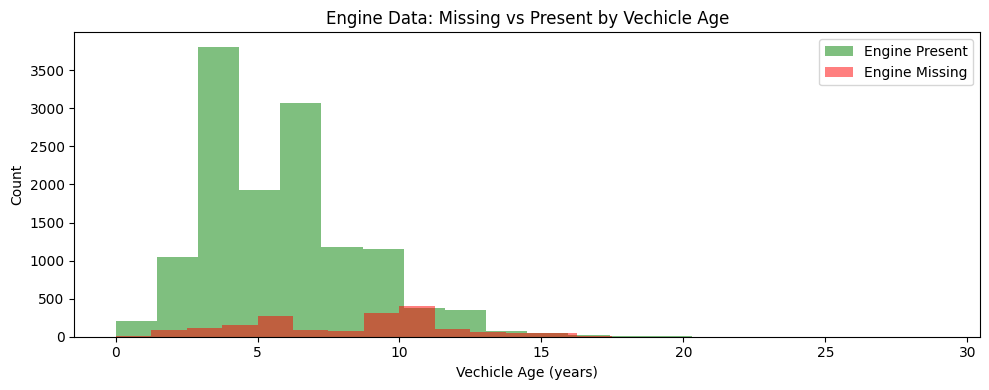

In [350]:
#Engine missing values 
engine_missing=df[df['engine'].isna()]['vehicle_age']
engine_present=df[df['engine'].notna()]['vehicle_age']

print(f"The Average vechile age where engine is missing:{engine_missing.mean():.1f} years ")
print(f"The Average vechile age where engine is present:{engine_present.mean():.1f} years ")

#Visualize it
fig,ax=plt.subplots(figsize=(10,4))
ax.hist(engine_present,bins=20,alpha=0.5,label='Engine Present',color='green')
ax.hist(engine_missing,bins=20,alpha=0.5,label='Engine Missing',color='red')
ax.set_xlabel('Vechicle Age (years)')
ax.set_ylabel('Count')
ax.set_title('Engine Data: Missing vs Present by Vechicle Age')
ax.legend()
plt.tight_layout()
plt.show()

In [351]:
print("Engine Distribution :")
print(f"Mean: {df['engine'].mean():.0f} cc")
print(f"Median: {df['engine'].median():.0f} cc")

Engine Distribution :
Mean: 1479 cc
Median: 1248 cc


In [352]:
df['mileage']=df['mileage'].astype(str).str.replace('kmpl','').str.replace('kmp','').str.strip()

df['mileage']=pd.to_numeric(df['mileage'],errors='coerce')
df['mileage'].head()

0    19.87
1    33.54
2      NaN
3    15.40
4    16.00
Name: mileage, dtype: float64

In [353]:
for col in ['engine','mileage','max_power']:
    median_val=df[col].median()
    df[col]=df[col].fillna(median_val)
    print(f"Filled {col} missing values with Median : {median_val}")
    

Filled engine missing values with Median : 1248.0
Filled mileage missing values with Median : 19.67
Filled max_power missing values with Median : 88.5


In [354]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15065 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15065 non-null  object 
 1   brand              15065 non-null  object 
 2   model              15065 non-null  object 
 3   vehicle_age        15065 non-null  int64  
 4   km_driven          15065 non-null  int64  
 5   seller_type        15065 non-null  object 
 6   fuel_type          15065 non-null  object 
 7   transmission_type  15065 non-null  object 
 8   mileage            15065 non-null  float64
 9   engine             15065 non-null  float64
 10  max_power          15065 non-null  float64
 11  seats              15065 non-null  float64
 12  selling_price      15065 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


In [355]:
#NO missing values present
df.isnull().sum()*100/df.shape[0]

car_name             0.0
brand                0.0
model                0.0
vehicle_age          0.0
km_driven            0.0
seller_type          0.0
fuel_type            0.0
transmission_type    0.0
mileage              0.0
engine               0.0
max_power            0.0
seats                0.0
selling_price        0.0
dtype: float64

In [356]:
#Duplicated clauses
df.duplicated().sum()

np.int64(290)

In [357]:
df=df.drop_duplicates()
df.duplicated().sum()   

np.int64(0)

In [358]:
df.shape

(14775, 13)

In [359]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,14775.000000,1.477500e+04,14775.000000,14775.000000,14775.000000,14775.000000,1.477500e+04
mean,6.040068,5.561718e+04,19.690294,1452.057394,100.013907,5.324332,1.046676e+06
std,3.015980,5.216780e+04,4.003120,485.674045,42.005054,0.806927,1.646418e+07
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,5.000000e+02
25%,4.000000,3.000000e+04,17.095000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.550000e+05
75%,8.000000,7.000000e+04,22.320000,1498.000000,113.420000,5.000000,8.235000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,1.000000e+09


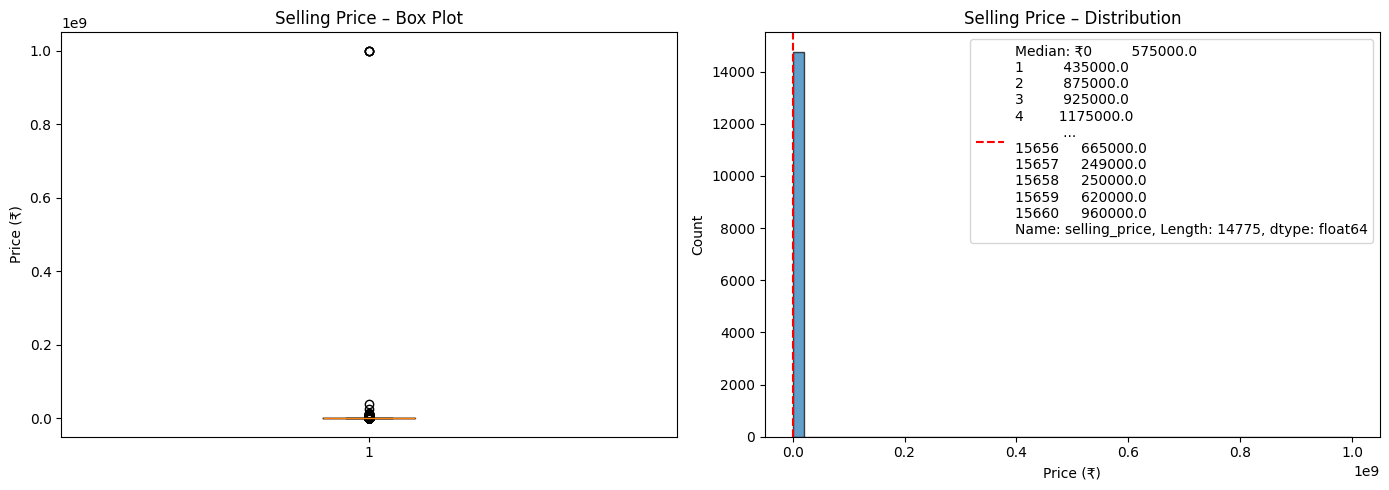

Clearly wrong values:
 Prices = 999999999: 4 rows
 Prices < 1000: 4 rows


In [360]:
# Visualize outliers in selling_price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Box plot
axes[0].boxplot(df['selling_price'].dropna(), vert=True)
axes[0].set_title('Selling Price – Box Plot')
axes[0].set_ylabel('Price (₹)')

#Histogram
axes[1].hist(df['selling_price'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Selling Price – Distribution')
axes[1].set_xlabel('Price (₹)')
axes[1].set_ylabel('Count')
axes[1].axvline(x=df['selling_price'].median(), color='red', linestyle='--', label=f"Median: ₹{df['selling_price']}")
axes[1].legend()

plt.tight_layout()
plt.show()

#The obvious errors
print("Clearly wrong values:")
print(f" Prices = 999999999: {(df['selling_price'] == 999999999).sum()} rows")
print(f" Prices < 1000: {(df['selling_price'] < 1000).sum()} rows")

In [361]:
# Remove clearly erroneous prices
before = len(df)

# Remove the 999999999 entries (data entry errors)
df = df[df['selling_price'] != 999999999]

# Remove suspiciously low prices (< ₹10,000 for a car is not realistic)
df = df[df['selling_price'] >= 10000]
after = len(df)
print(f"Removed {before - after} rows with impossible values")
print(f"Remaining rows: {after}")

Removed 8 rows with impossible values
Remaining rows: 14767


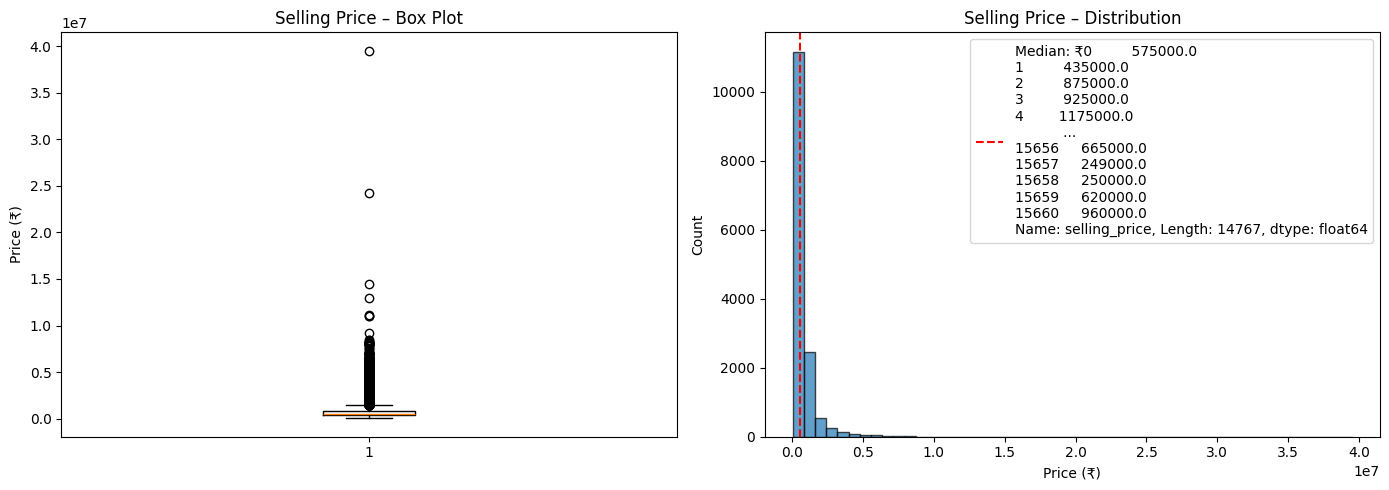

Clearly wrong values:
 Prices = 999999999: 0 rows
 Prices < 1000: 0 rows


In [362]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Box plot
axes[0].boxplot(df['selling_price'].dropna(), vert=True)
axes[0].set_title('Selling Price – Box Plot')
axes[0].set_ylabel('Price (₹)')

#Histogram
axes[1].hist(df['selling_price'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Selling Price – Distribution')
axes[1].set_xlabel('Price (₹)')
axes[1].set_ylabel('Count')
axes[1].axvline(x=df['selling_price'].median(), color='red', linestyle='--', label=f"Median: ₹{df['selling_price']}")
axes[1].legend()

plt.tight_layout()
plt.show()

#The obvious errors
print("Clearly wrong values:")
print(f" Prices = 999999999: {(df['selling_price'] == 999999999).sum()} rows")
print(f" Prices < 1000: {(df['selling_price'] < 1000).sum()} rows")

In [363]:
df.head(20)

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,Cng,Manual,33.54,998.0,67.04,5.0,435000.0
2,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,19.67,1497.0,117.60,5.0,875000.0
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,Dealer,Diesel,Manual,15.40,2179.0,88.50,8.0,925000.0
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.00,2179.0,140.00,7.0,1175000.0
5,Hyundai i10,Hyundai,i10,12,73000,Dealer,Petrol,Manual,20.36,1197.0,78.90,5.0,190000.0
6,Hyundai i20,Hyundai,i20,12,88000,Dealer,Petrol,Manual,18.50,1248.0,80.00,5.0,275000.0
7,Maruti Wagon R,Maruti,Wagon R,7,50000,Individual,Petrol,Manual,20.51,1248.0,67.04,5.0,351000.0
8,Ford Freestyle,Ford,Freestyle,2,30000,Individual,Diesel,Manual,24.40,1498.0,98.63,5.0,775000.0
9,Maruti Swift Dzire,Maruti,Swift Dzire,10,75220,Dealer,Diesel,Manual,19.30,1248.0,73.90,5.0,390000.0


In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14767 entries, 0 to 15660
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           14767 non-null  object 
 1   brand              14767 non-null  object 
 2   model              14767 non-null  object 
 3   vehicle_age        14767 non-null  int64  
 4   km_driven          14767 non-null  int64  
 5   seller_type        14767 non-null  object 
 6   fuel_type          14767 non-null  object 
 7   transmission_type  14767 non-null  object 
 8   mileage            14767 non-null  float64
 9   engine             14767 non-null  float64
 10  max_power          14767 non-null  float64
 11  seats              14767 non-null  float64
 12  selling_price      14767 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.6+ MB


In [365]:
#Encoding 
df['transmission_type'].value_counts()

transmission_type
Manual       11699
Automatic     3068
Name: count, dtype: int64

In [366]:
#Label encoding because transmission_type contains only manual/automatic 
df['transmission_type']=df['transmission_type'].map({'Manual':0,'Automatic':1})
df.head(20)

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,0,19.87,1461.0,83.80,5.0,575000.0
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,Cng,0,33.54,998.0,67.04,5.0,435000.0
2,Honda City,Honda,City,3,48959,Dealer,Petrol,0,19.67,1497.0,117.60,5.0,875000.0
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,Dealer,Diesel,0,15.40,2179.0,88.50,8.0,925000.0
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,1,16.00,2179.0,140.00,7.0,1175000.0
5,Hyundai i10,Hyundai,i10,12,73000,Dealer,Petrol,0,20.36,1197.0,78.90,5.0,190000.0
6,Hyundai i20,Hyundai,i20,12,88000,Dealer,Petrol,0,18.50,1248.0,80.00,5.0,275000.0
7,Maruti Wagon R,Maruti,Wagon R,7,50000,Individual,Petrol,0,20.51,1248.0,67.04,5.0,351000.0
8,Ford Freestyle,Ford,Freestyle,2,30000,Individual,Diesel,0,24.40,1498.0,98.63,5.0,775000.0
9,Maruti Swift Dzire,Maruti,Swift Dzire,10,75220,Dealer,Diesel,0,19.30,1248.0,73.90,5.0,390000.0


In [367]:
df['transmission_type'].value_counts()

transmission_type
0    11699
1     3068
Name: count, dtype: int64

In [368]:
df['fuel_type'].value_counts()

fuel_type
Petrol      7334
Diesel      7098
Cng          287
Lpg           44
Electric       4
Name: count, dtype: int64

In [369]:
#One-Hot Encoding because it contains more types of values 
print(f"Before One-Hot Encoding the columns {df.shape}")


Before One-Hot Encoding the columns (14767, 13)


In [370]:
df=pd.get_dummies(df,columns=['fuel_type'],drop_first=True)
df.head(20)

,car_name,brand,model,vehicle_age,km_driven,seller_type,transmission_type,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol
0,Renault Duster,Renault,Duster,7,67647,Dealer,0,19.87,1461.0,83.80,5.0,575000.0,True,False,False,False
1,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,0,33.54,998.0,67.04,5.0,435000.0,False,False,False,False
2,Honda City,Honda,City,3,48959,Dealer,0,19.67,1497.0,117.60,5.0,875000.0,False,False,False,True
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,Dealer,0,15.40,2179.0,88.50,8.0,925000.0,True,False,False,False
4,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,1,16.00,2179.0,140.00,7.0,1175000.0,True,False,False,False
5,Hyundai i10,Hyundai,i10,12,73000,Dealer,0,20.36,1197.0,78.90,5.0,190000.0,False,False,False,True
6,Hyundai i20,Hyundai,i20,12,88000,Dealer,0,18.50,1248.0,80.00,5.0,275000.0,False,False,False,True
7,Maruti Wagon R,Maruti,Wagon R,7,50000,Individual,0,20.51,1248.0,67.04,5.0,351000.0,False,False,False,True
8,Ford Freestyle,Ford,Freestyle,2,30000,Individual,0,24.40,1498.0,98.63,5.0,775000.0,True,False,False,False
9,Maruti Swift Dzire,Maruti,Swift Dzire,10,75220,Dealer,0,19.30,1248.0,73.90,5.0,390000.0,True,False,False,False


In [371]:
print(f"After One-Hot Encoding {df.shape}")

After One-Hot Encoding (14767, 16)


In [372]:
df['seller_type'].value_counts()

seller_type
Dealer              9152
Individual          5449
Trustmark Dealer     166
Name: count, dtype: int64

In [373]:
df=pd.get_dummies(df,columns=['seller_type'],drop_first=True)

In [374]:
df.head(10)

,car_name,brand,model,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer
0,Renault Duster,Renault,Duster,7,67647,0,19.87,1461.0,83.80,5.0,575000.0,True,False,False,False,False,False
1,Maruti Wagon R,Maruti,Wagon R,3,52000,0,33.54,998.0,67.04,5.0,435000.0,False,False,False,False,False,False
2,Honda City,Honda,City,3,48959,0,19.67,1497.0,117.60,5.0,875000.0,False,False,False,True,False,False
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,0,15.40,2179.0,88.50,8.0,925000.0,True,False,False,False,False,False
4,Mahindra XUV500,Mahindra,XUV500,4,34000,1,16.00,2179.0,140.00,7.0,1175000.0,True,False,False,False,False,False
5,Hyundai i10,Hyundai,i10,12,73000,0,20.36,1197.0,78.90,5.0,190000.0,False,False,False,True,False,False
6,Hyundai i20,Hyundai,i20,12,88000,0,18.50,1248.0,80.00,5.0,275000.0,False,False,False,True,False,False
7,Maruti Wagon R,Maruti,Wagon R,7,50000,0,20.51,1248.0,67.04,5.0,351000.0,False,False,False,True,True,False
8,Ford Freestyle,Ford,Freestyle,2,30000,0,24.40,1498.0,98.63,5.0,775000.0,True,False,False,False,True,False
9,Maruti Swift Dzire,Maruti,Swift Dzire,10,75220,0,19.30,1248.0,73.90,5.0,390000.0,True,False,False,False,False,False


In [377]:
df[['seller_type_Individual','seller_type_Trustmark Dealer']]

,seller_type_Individual,seller_type_Trustmark Dealer
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
15656,False,False
15657,False,False
15658,True,False
15659,False,False


In [ ]:
#Encoding is done we can also encode the band_name using One-Hot encoding 

In [378]:
#Clean Data
df.head(20)

,car_name,brand,model,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer
0,Renault Duster,Renault,Duster,7,67647,0,19.87,1461.0,83.80,5.0,575000.0,True,False,False,False,False,False
1,Maruti Wagon R,Maruti,Wagon R,3,52000,0,33.54,998.0,67.04,5.0,435000.0,False,False,False,False,False,False
2,Honda City,Honda,City,3,48959,0,19.67,1497.0,117.60,5.0,875000.0,False,False,False,True,False,False
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,0,15.40,2179.0,88.50,8.0,925000.0,True,False,False,False,False,False
4,Mahindra XUV500,Mahindra,XUV500,4,34000,1,16.00,2179.0,140.00,7.0,1175000.0,True,False,False,False,False,False
5,Hyundai i10,Hyundai,i10,12,73000,0,20.36,1197.0,78.90,5.0,190000.0,False,False,False,True,False,False
6,Hyundai i20,Hyundai,i20,12,88000,0,18.50,1248.0,80.00,5.0,275000.0,False,False,False,True,False,False
7,Maruti Wagon R,Maruti,Wagon R,7,50000,0,20.51,1248.0,67.04,5.0,351000.0,False,False,False,True,True,False
8,Ford Freestyle,Ford,Freestyle,2,30000,0,24.40,1498.0,98.63,5.0,775000.0,True,False,False,False,True,False
9,Maruti Swift Dzire,Maruti,Swift Dzire,10,75220,0,19.30,1248.0,73.90,5.0,390000.0,True,False,False,False,False,False


In [383]:
df.describe()

,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,selling_price
count,14767.000000,1.476700e+04,14767.000000,14767.000000,14767.000000,14767.000000,14767.000000,1.476700e+04
mean,6.039683,5.562069e+04,0.207761,19.691184,1452.099140,100.014264,5.324236,7.763684e+05
std,3.015522,5.217968e+04,0.405718,4.002790,485.788943,42.015248,0.806883,9.038042e+05
min,0.000000,1.000000e+02,0.000000,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,0.000000,17.100000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,0.000000,19.670000,1248.000000,88.500000,5.000000,5.550000e+05
75%,8.000000,7.000000e+04,0.000000,22.320000,1498.000000,113.420000,5.000000,8.215000e+05
max,29.000000,3.800000e+06,1.000000,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [380]:
df.shape

(14767, 17)

In [382]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14767 entries, 0 to 15660
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   car_name                      14767 non-null  object 
 1   brand                         14767 non-null  object 
 2   model                         14767 non-null  object 
 3   vehicle_age                   14767 non-null  int64  
 4   km_driven                     14767 non-null  int64  
 5   transmission_type             14767 non-null  int64  
 6   mileage                       14767 non-null  float64
 7   engine                        14767 non-null  float64
 8   max_power                     14767 non-null  float64
 9   seats                         14767 non-null  float64
 10  selling_price                 14767 non-null  float64
 11  fuel_type_Diesel              14767 non-null  bool   
 12  fuel_type_Electric            14767 non-null  bool   
 13  fuel_t